In [35]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [36]:
# Load embeddings
import torch

data = torch.load("../outputs/resnet_embeddings.pt")


In [37]:
# Extract features and labels
features = data["features"]
labels = data["labels"]

print(features.shape)
print(type(labels), labels[:5])

torch.Size([800, 2048])
<class 'list'> [1, 1, 0, 1, 1]


In [38]:
# Convert to numpy
if isinstance(features, torch.Tensor):
    features = features.cpu().numpy()

print("Final shape:", features.shape)
print("Final type:", type(features))

Final shape: (800, 2048)
Final type: <class 'numpy.ndarray'>


In [39]:
# Scale embeddings
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [40]:
# Dimensionality reduction with PCA
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

print("After PCA:", X_pca.shape)

After PCA: (800, 50)


In [41]:
# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca)

print("t-SNE output:", X_tsne.shape)

t-SNE output: (800, 2)


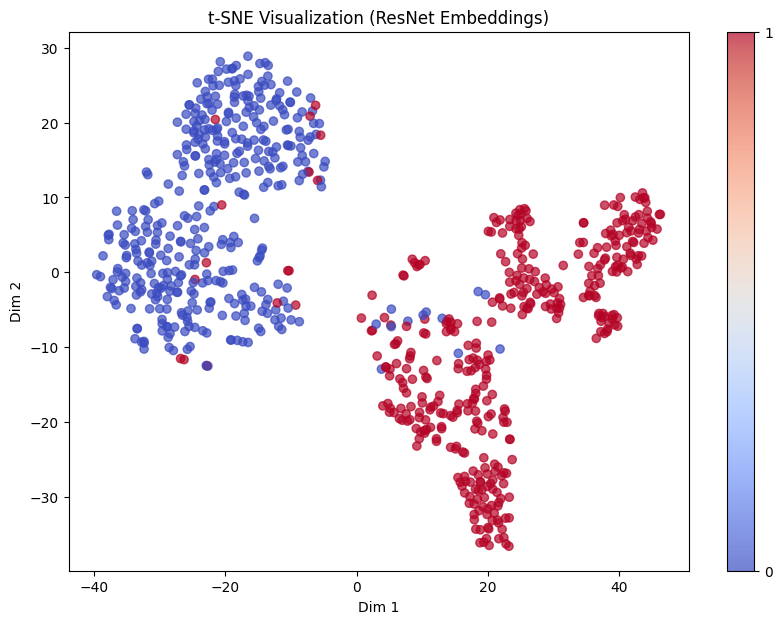

In [57]:
# Plotting
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=labels_encoded,
    cmap='coolwarm',
    alpha=0.7
)

cbar = plt.colorbar(scatter)

cbar.set_ticks(range(len(le.classes_)))
cbar.set_ticklabels(le.classes_)

plt.title("t-SNE Visualization (ResNet Embeddings)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

output_path = "../outputs/plots/tsne_fake_vs_genuine.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()